In [30]:
##basic deeb agent
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [31]:
from tavily import TavilyClient
tavily_client=TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [40]:
from typing import Literal

def web_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "technology", "sports", "entertainment"] = "general",
    include_snippets: bool = False,
):
    """
    Search the web using Tavily and return relevant results.
    
    Args:
        query: Search query.
        max_results: Number of results to return.
        topic: Search category.
        include_snippets: Whether to include raw content snippets.
    """
    
    results = tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_snippets,
        topic=topic,
    )
    
    return results

In [34]:
from langchain.chat_models import init_chat_model
model=init_chat_model("groq:qwen/qwen3-32b")
model

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000019996552D80>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000019996552FF0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [35]:
print(type(model))

response = model.invoke("Hello")
print(response)

<class 'langchain_groq.chat_models.ChatGroq'>
content='<think>\nOkay, the user said "Hello". I need to respond appropriately. Since it\'s a greeting, I should reply with a friendly greeting. Maybe ask how I can assist them. Keep it open-ended so they can specify what they need help with. Make sure the tone is welcoming and helpful. Let me check if there are any other considerations. No, this seems straightforward. Alright, time to craft a response.\n</think>\n\nHello! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know! 😊' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 9, 'total_tokens': 127, 'completion_time': 0.211267116, 'completion_tokens_details': None, 'prompt_time': 0.000252085, 'prompt_tokens_details': None, 'queue_time': 0.053264145, 'total_time': 0.211519201}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'f

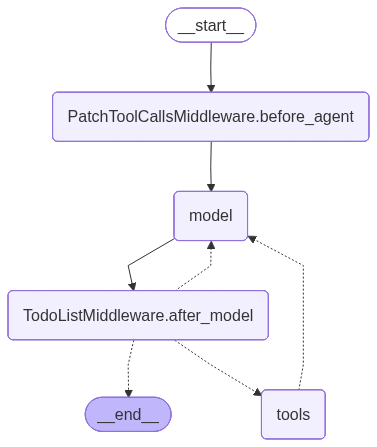

In [43]:
from deepagents import create_deep_agent
deepagent = create_deep_agent(
    model="google_genai:gemini-3.5-flash",
    tools=[web_search],
    system_prompt="You are a helpful assistant."
)
deepagent

In [38]:
result = tavily_client.search(
    query="weather in San Francisco",
    max_results=3
)

print(result)

{'query': 'weather in San Francisco', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'Weather in San Francisco', 'url': 'https://www.weatherapi.com/', 'content': "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1780729331, 'localtime': '2026-06-06 00:02'}, 'current': {'last_updated_epoch': 1780728300, 'last_updated': '2026-06-05 23:45', 'temp_c': 12.8, 'temp_f': 55.0, 'is_day': 0, 'condition': {'text': 'Partly cloudy', 'icon': '//cdn.weatherapi.com/weather/64x64/night/116.png', 'code': 1003}, 'wind_mph': 10.1, 'wind_kph': 16.2, 'wind_degree': 268, 'wind_dir': 'W', 'pressure_mb': 1010.0, 'pressure_in': 29.84, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 77, 'cloud': 50, 'feelslike_c': 11.2, 'feelslike_f': 52.2, 'windchill_c': 13.1, 'windchill_f': 55.6, 'heatindex_c': 14.3, 'heatindex_f': 57.7, 'dewpoint_c': 8.7, 'd

In [45]:
res=deepagent.invoke(
    {"messages": [{"role": "user", "content": "what is langgraph?"}]})

res

{'messages': [HumanMessage(content='what is langgraph?', additional_kwargs={}, response_metadata={}, id='07478f18-c981-433d-a119-be54ff0a2217'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "what is langgraph langchain"}'}, '__gemini_function_call_thought_signatures__': {'5w9ald5b': 'EpAHCo0HAQw51sduxPTHwXFoMyh8mXwNE5bn8TSbIdds7adJUe0HqD1CloLyHx6NBeXeGd6FtN4avTytT/2WkfNvL8WlZRB6ipINKsPLq44rI5hg0lF0zHPsIhmEnEMeuPgEP5E2mSZYHgF9bIl+lz21y/ZQlpxjXSOXsGA+1TfCJpejYElz+68SNHpMFshpjCt/3ibb1pjWhfrbA1El4PYnROlV3mbbVgOiZtrrsRUK64gFqc14bm7QMhG2rFd+op/x61QI6ASoZRO2EBzLf4QtFvu0swPagQfAxEicfCHg9to/HhIGpFnVLrXDikyZCki9UdQ4wfsUy0z5P5pJ9j/bNpfYkhHCbgkJxZSR+GxN5lFHM9o2qUPCu+Q84fuTA28JRnPri4Dpk/6QoMM55+hTztHmJbSLTWJ+mHysyTDYDgipEw3BfBkkgHkttEiFgYj2Wh6KOBo2JK1jDNdy/EE/OP1b+ZOn93HKrgFyuvMxd2EqpZ3NInF3PY8EpJxUH8KjlOc5Ay6WusYGedUrtgPDCHfr5X1fNIaPGQyJBMvnmwBcTI5gPRODb+WtFiZerKvC55HpEnob4U5x+5klXA0UjV3ra4l3yOWJzOrT9QNY8x/y1BensvYQ9XOlc7/i5k7T+aVLULYGL

In [46]:
res["messages"][-1].content

[{'type': 'text',
  'text': '**LangGraph** is an open-source framework developed by LangChain designed for building stateful, multi-agent, and complex generative AI workflows. \n\nWhile LangChain is optimized for linear, sequence-based pipelines (chains), LangGraph is built to support **cyclic workflows** (loops) where an AI needs to repeatedly plan, execute, reflect, and refine its actions.\n\n### Key Concepts\n\n1. **State Management**: LangGraph is centered around a shared, persistent state object (the "State") that is passed between different steps of the workflow. Each step can read from, update, or append to this state.\n2. **Graph-Based Architecture**: Workflows are modeled as graphs:\n   - **Nodes**: Represent functions, tools, or LLM calls that execute work and modify the state.\n   - **Edges**: Define the execution flow between nodes. These can be conditional (e.g., branching based on the LLM\'s output or tool results).\n3. **Cycles and Loops**: Unlike standard Directed Acycl

In [47]:
res["files"]

{}